# Preference Aggregation in RLHF — A Hands-On Tutorial

**Course context.** Week 4 lecture (`docs/04.md` §2): *RLHF is a voting rule in disguise*. The reward model is a Bradley–Terry fit on human pairwise preferences, and the policy is then trained against that reward. Once you see this, the natural question is: *what if we had used a different aggregation rule?*

**What this notebook does.** Take a small set of human preferences over three LLM responses and run them through four classical aggregation rules — **Plurality, Borda, Condorcet (pairwise majority), and Bradley–Terry–Luce (BTL)**. Show that the same ratings produce *different winners* depending on the rule. Then point at two real-world preference datasets — PRISM and Community Alignment — where you can repeat the exercise at scale.

**Prerequisites.** `numpy`, `matplotlib`, `scipy`.

```bash
pip install numpy matplotlib scipy
```


## §1 — From RLHF preference data to a voting rule

The standard RLHF pipeline (Christiano et al. 2017; Ouyang et al. 2022) has three stages:

1. **Pretrain** a base language model on web text.
2. **Reward model.** For each prompt, sample several model responses. Show pairs to human raters; ask which is better. Fit a Bradley–Terry model — assigning each response a scalar score $s$ such that $P(i \succ j) = \sigma(s_i - s_j)$ — to those pairwise comparisons. The fitted scores *are* the reward.
3. **Policy fine-tune.** Train the base model with reinforcement learning to maximise the reward-model score on its outputs.

Step (2) is where many heterogeneous human preferences become one scalar per response. **It is a voting rule.** The specific rule used in standard RLHF is Bradley–Terry MLE on pairwise data — but Bradley–Terry is one rule among many. Borda, Kemeny–Young, Condorcet, plurality all operate on the same pairwise/ranking inputs and would assign different rewards.

**This notebook makes that choice visible** by running four rules on the same toy ratings and watching the winner change.


## §2 — A toy preference dataset

Imagine a single prompt sent to three LLMs — *"What would you say to a friend whose father just died?"* — and three different responses:

- **A — Warm/emotional.** *"I'm so sorry for your loss. Grief takes many forms; give yourself permission to feel whatever comes up, and don't rush yourself."*
- **B — Clinical/practical.** *"Most people recover from grief within 6–12 months. Maintain regular routines, exercise, and seek therapy if symptoms persist."*
- **C — Philosophical/meaning-making.** *"Death is an inevitable part of human existence. Reflect on your father's life, the values he passed on, and honour him through your own actions."*

Seven raters, with deliberately different sensibilities, rank the three responses:

| Rater | Profile               | Ranking      |
|-------|-----------------------|--------------|
| R1    | marriage counsellor   | A > C > B    |
| R2    | software engineer     | B > A > C    |
| R3    | retired teacher       | C > A > B    |
| R4    | ER physician          | B > C > A    |
| R5    | philosophy professor  | C > A > B    |
| R6    | social-work student   | A > C > B    |
| R7    | hedge-fund analyst    | B > A > C    |

This is the kind of preference data RLHF collects (pairwise or ranked). Below, we run four aggregation rules and watch them disagree.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Each row is one rater's full ranking, top to bottom.
# 'A', 'B', 'C' are the three LLM responses.
RANKINGS = [
    ["A", "C", "B"],   # R1 — marriage counsellor
    ["B", "A", "C"],   # R2 — software engineer
    ["C", "A", "B"],   # R3 — retired teacher
    ["B", "C", "A"],   # R4 — ER physician
    ["C", "A", "B"],   # R5 — philosophy professor
    ["A", "C", "B"],   # R6 — social-work student
    ["B", "A", "C"],   # R7 — hedge-fund analyst
]
ALTERNATIVES = ["A", "B", "C"]
N_RATERS = len(RANKINGS)
print(f"{N_RATERS} raters, {len(ALTERNATIVES)} alternatives.")


7 raters, 3 alternatives.


## §3 — Four classical aggregation rules

The same seven rankings, four different ways to collapse them into a single winner. Each rule embeds a different value:

- **§3.1 Plurality** — only first-place votes count.
- **§3.2 Borda** — every rank position contributes points.
- **§3.3 Condorcet** — pairwise majority across every pair.
- **§3.4 Bradley–Terry** — fit a latent quality score (and the rule RLHF actually uses).

Each subsection implements its rule from scratch in ~15 lines and reports the winner on the toy data.


### §3.1 Plurality — first-place votes only

The simplest rule. Each rater votes for their **top choice** only; whoever has the most first-place votes wins.

Plurality is what most people picture when they say *"voting"* — and it is exactly what a "best-of-N" sampler implements when it picks the top-rated response per query.


In [17]:
def plurality(rankings, alternatives):
    """Count first-place votes for each alternative."""
    counts = {a: 0 for a in alternatives}
    for r in rankings:
        counts[r[0]] += 1
    return counts

plurality_counts = plurality(RANKINGS, ALTERNATIVES)
plurality_winner = max(plurality_counts, key=plurality_counts.get)
print("First-place votes:", plurality_counts)
print("Plurality winner:  ", plurality_winner)


First-place votes: {'A': 2, 'B': 3, 'C': 2}
Plurality winner:   B


### §3.2 Borda count — points for every rank

Each rater's full ranking matters, not just the top. With $k$ alternatives, a rater's top choice gets $k-1$ points, second-from-top gets $k-2$, …, last gets $0$. Sum across raters; highest score wins.

Borda *uses information about second-place support*, which plurality discards. An alternative that is everyone's second choice can lose under plurality and win under Borda.


In [18]:
def borda(rankings, alternatives):
    """Borda count: with k alternatives, position i (0-indexed top) gets (k-1-i) points."""
    k = len(alternatives)
    scores = {a: 0 for a in alternatives}
    for r in rankings:
        for i, a in enumerate(r):
            scores[a] += (k - 1 - i)
    return scores

borda_scores = borda(RANKINGS, ALTERNATIVES)
borda_winner = max(borda_scores, key=borda_scores.get)
print("Borda scores:", borda_scores)
print("Borda winner:", borda_winner)


Borda scores: {'A': 8, 'B': 6, 'C': 7}
Borda winner: A


### §3.3 Condorcet — pairwise majority

For every pair $(i, j)$, count how many raters prefer $i$ to $j$. If some alternative beats *every other* alternative in pairwise majority, it is the **Condorcet winner**. If no such alternative exists, there is a *Condorcet cycle* (see §5) and the rule is undefined.

Condorcet is the most robustly "majoritarian" rule: by construction, no other alternative can defeat the Condorcet winner head-to-head.


In [19]:
def pairwise_wins(rankings, alternatives):
    """For each (i, j), count raters who prefer i to j."""
    n = len(alternatives)
    W = np.zeros((n, n), dtype=int)
    for r in rankings:
        pos = {a: r.index(a) for a in alternatives}
        for i, a in enumerate(alternatives):
            for j, b in enumerate(alternatives):
                if i != j and pos[a] < pos[b]:
                    W[i, j] += 1
    return W

W = pairwise_wins(RANKINGS, ALTERNATIVES)
print("Pairwise wins matrix W (rows beat columns):")
print(f"      {'   '.join(ALTERNATIVES)}")
for i, a in enumerate(ALTERNATIVES):
    print(f"  {a}   {W[i]}")

def condorcet_winner(W, alternatives):
    n = len(alternatives)
    for i in range(n):
        if all(W[i, j] > W[j, i] for j in range(n) if j != i):
            return alternatives[i]
    return None  # cycle, no Condorcet winner

cw = condorcet_winner(W, ALTERNATIVES)
print(f"\nCondorcet winner: {cw}" if cw else "\nNo Condorcet winner (cycle).")


Pairwise wins matrix W (rows beat columns):
      A   B   C
  A   [0 4 4]
  B   [3 0 3]
  C   [3 4 0]

Condorcet winner: A


### §3.4 Bradley–Terry–Luce — the rule RLHF actually uses

The aggregation rule actually used by RLHF reward models. Each alternative gets a latent log-score $s_i$, and the probability that $i$ beats $j$ is

$$P(i \succ j) \;=\; \sigma(s_i - s_j) \;=\; \frac{e^{s_i}}{e^{s_i} + e^{s_j}}.$$

Given the pairwise wins matrix $W$ from §3.3, fit the scores by maximum likelihood. The MLE has no closed form, but the log-likelihood is concave so any standard optimiser converges. Scores are identified only up to an additive constant — we centre them at $0$.

The "BTL winner" is the alternative with the highest fitted score.


In [20]:
def btl_neg_log_likelihood(s, W):
    """Negative log-likelihood of the Bradley–Terry model on log-scores s."""
    n = len(s)
    ll = 0.0
    for i in range(n):
        for j in range(n):
            if i != j and W[i, j] > 0:
                # log P(i > j) = s_i - logsumexp(s_i, s_j)  (numerically stable)
                m = max(s[i], s[j])
                lse = m + np.log(np.exp(s[i] - m) + np.exp(s[j] - m))
                ll += W[i, j] * (s[i] - lse)
    return -ll

def btl_fit(W):
    n = W.shape[0]
    s0 = np.zeros(n)
    res = minimize(btl_neg_log_likelihood, s0, args=(W,), method="BFGS")
    return res.x - res.x.mean()  # centre

btl_scores = btl_fit(W)
btl_winner = ALTERNATIVES[int(np.argmax(btl_scores))]
print("Bradley–Terry log-scores (centred):")
for a, s in zip(ALTERNATIVES, btl_scores):
    print(f"  {a}: {s:+.3f}")
print(f"\nBTL winner: {btl_winner}")


Bradley–Terry log-scores (centred):
  A: +0.192
  B: -0.192
  C: +0.000

BTL winner: A


## §4 — Same data, different winners

Side-by-side: each rule's score for A, B, C on the *same* 7-rater dataset, plus the rule's winner.


In [ ]:
results = {
    "Plurality":     plurality_counts,
    "Borda":         borda_scores,
    "Condorcet":     {a: int(W[i].sum()) for i, a in enumerate(ALTERNATIVES)},  # total pairwise wins
    "Bradley-Terry": {a: float(s) for a, s in zip(ALTERNATIVES, btl_scores)},
}
winners = {
    "Plurality":     plurality_winner,
    "Borda":         borda_winner,
    "Condorcet":     cw if cw else "cycle",
    "Bradley-Terry": btl_winner,
}

print(f"""{'Rule':<16}{'A':>8}{'B':>8}{'C':>8}   Winner""")
print("-" * 50)
for rule, scores in results.items():
    row = f"{rule:<16}"
    for a in ALTERNATIVES:
        row += f"{scores[a]:>8.2f}"
    row += f"   {winners[rule]}"
    print(row)


### What just happened

- **Plurality** picked **B** — the practical/clinical response. Three raters (R2, R4, R7) put B first. The rule sees only those three top votes and ignores that *four other raters put B last*.
- **Borda, Condorcet, and Bradley–Terry** all picked **A** — the warm/emotional response. A wasn't the most-loved option, but it was *broadly accepted*: it beat both other options in pairwise majority and accumulated more total support across the ranks.

The same seven raters' opinions, four different rules, two different "winners". This is not a quirk of the toy data — it is Arrow's theorem in miniature: every aggregation rule embeds different fairness desiderata, and the rules disagree whenever preferences are not unanimous.

**The implication for RLHF.** Standard RLHF picks Bradley–Terry for the reward model. If the same human pairwise preferences had been aggregated under plurality (a "best-of-N first-place vote" rule) the *reward* — and therefore the trained model's behaviour — would have been different.


## §5 — When pairwise majority breaks: the Condorcet paradox

Sometimes there is no Condorcet winner at all. The classic example (Condorcet 1785):

| Rater | Ranking      |
|-------|--------------|
| V1    | A > B > C    |
| V2    | B > C > A    |
| V3    | C > A > B    |

Pairwise: A beats B (V1, V3), B beats C (V1, V2), *and C beats A (V2, V3)*. The "majority preference" is a cycle. No alternative dominates.

In RLHF, this is the formal counterpart of *"the human preferences are inconsistent enough that no scalar reward can faithfully represent them"* — Arrow's impossibility, made concrete.


In [22]:
CYCLE_RANKINGS = [
    ["A", "B", "C"],
    ["B", "C", "A"],
    ["C", "A", "B"],
]
W_cycle = pairwise_wins(CYCLE_RANKINGS, ALTERNATIVES)
print("Pairwise wins:")
print(f"      {'   '.join(ALTERNATIVES)}")
for i, a in enumerate(ALTERNATIVES):
    print(f"  {a}   {W_cycle[i]}")
print(f"\nCondorcet winner: {condorcet_winner(W_cycle, ALTERNATIVES) or 'NONE — cycle'}")
print(f"BTL log-scores:   {btl_fit(W_cycle).round(3)}  (all equal — symmetric profile)")


Pairwise wins:
      A   B   C
  A   [0 2 1]
  B   [1 0 2]
  C   [2 1 0]

Condorcet winner: NONE — cycle
BTL log-scores:   [0. 0. 0.]  (all equal — symmetric profile)


## §6 — Why this matters for RLHF

The reward model in RLHF *is* a Bradley–Terry fit on pairwise human comparisons. So in this notebook's vocabulary, RLHF is **§3.4 applied at scale** — millions of pairwise comparisons across many prompts. Three things follow:

1. **The choice of BTL is a normative choice, not a technical one.** It happened to be the easiest to fit and to plug into RL — but Borda over rankings, Kemeny–Young, or weighted variants would aggregate the same preferences differently and give different rewards.
2. **Arrow's theorem applies.** [Mishra (2023)](https://arxiv.org/abs/2310.16048) formalises this: under standard fairness conditions, no aggregation rule including BTL can satisfy them all simultaneously. RLHF inherits the impossibility.
3. **Heterogeneous preferences are not noise.** Rules disagree precisely *when raters disagree*. Averaging that disagreement away — what BTL does — is one specific way of resolving it, and may suppress minority preferences systematically (Conitzer et al. 2024).

The natural research move: take a real preference dataset and re-aggregate it under a different rule. That is the focus of the next section.


## §7 — Real-world preference data

The toy walkthrough made the abstract point. Now we load two open preference datasets and re-run the aggregation logic at scale, picking one *subgroup question* per dataset. Both subsections download their data on first run (cached locally to `./data/`, gitignored) and use **Bradley–Terry** — the rule RLHF actually uses — as the working aggregator.

- **§7.1 PRISM** — small, deep, individualised. Do *men and women* prefer the same LLMs?
- **§7.2 Community Alignment** — large, multilingual, candidate-diverse. Does *response choice* depend on the rater's country?


### §7.1 PRISM (Kirk et al. 2024) — do men and women prefer the same LLMs?

**The dataset.** 1,500 participants from 75 countries; 8,011 conversations with 21 LLMs; 68,371 utterances. Every response rated 0–100 on a continuous slider. Every rating links to a detailed participant profile — age, gender, country, religion, English proficiency — *plus* a self-written "system string" (personal constitution) and free-text values description. The richest per-rater metadata of any open alignment dataset.

🤗 [huggingface.co/datasets/HannahRoseKirk/prism-alignment](https://huggingface.co/datasets/HannahRoseKirk/prism-alignment) · 📄 [arXiv:2404.16019](https://arxiv.org/abs/2404.16019)

**The recipe.** Load the utterances (turn 0 only — that's where four LLMs respond to the same prompt). Look up each rater's gender from the survey. Build *two* pairwise wins matrices — one from male raters, one from female. Fit Bradley–Terry (§3.4) on each. Plot every model as a point: x = male BTL score, y = female BTL score. Diagonal = no gender difference.


In [23]:
# Download both files (cached in ./data/ on first run, instant after).
from huggingface_hub import hf_hub_download
from pathlib import Path
import json
from collections import defaultdict

DATA_DIR = Path.cwd() / "data"
DATA_DIR.mkdir(exist_ok=True)

utt_path = hf_hub_download("HannahRoseKirk/prism-alignment", "utterances.jsonl",
                           repo_type="dataset", cache_dir=str(DATA_DIR))
srv_path = hf_hub_download("HannahRoseKirk/prism-alignment", "survey.jsonl",
                           repo_type="dataset", cache_dir=str(DATA_DIR))

# Map every PRISM participant to their self-reported gender.
gender_of = {}
for line in open(srv_path):
    r = json.loads(line)
    gender_of[r["user_id"]] = r.get("gender")

# Group turn-0 utterances by (gender, conversation_id). Keep only Male / Female
# (Non-binary and Prefer-not-to-say are too small a sample for a clean BTL fit).
groups_by_gender = {"Male": defaultdict(list), "Female": defaultdict(list)}
for line in open(utt_path):
    u = json.loads(line)
    if u["turn"] != 0:
        continue
    g = gender_of.get(u["user_id"])
    if g in groups_by_gender:
        groups_by_gender[g][u["conversation_id"]].append((u["model_name"], u["score"]))

for g, gr in groups_by_gender.items():
    print(f"  {g:<8} {len(gr):>5} conversations")


  Male      4002 conversations
  Female    3885 conversations


In [24]:
import numpy as np
from scipy.optimize import minimize
from scipy.stats import spearmanr

# Stable model ordering across both genders
models = sorted({m for groups in groups_by_gender.values()
                   for g in groups.values()
                   for m, _ in g})
M = len(models)
idx = {m: i for i, m in enumerate(models)}

def pairwise_W(groups):
    '''Build a pairwise wins matrix from {conversation_id: [(model, score), ...]}.'''
    W = np.zeros((M, M), dtype=int)
    for g in groups.values():
        for a, sa in g:
            for b, sb in g:
                if sa > sb:
                    W[idx[a], idx[b]] += 1
    return W

def btl_fit(W):
    '''Bradley–Terry MLE; returns log-scores centred at 0.'''
    def neg_ll(s, W):
        Smat = s[:, None] - s[None, :]
        return -(W * (-np.logaddexp(0, -Smat))).sum()
    res = minimize(neg_ll, np.zeros(M), args=(W,), method="BFGS")
    return res.x - res.x.mean()

btl_male   = btl_fit(pairwise_W(groups_by_gender["Male"]))
btl_female = btl_fit(pairwise_W(groups_by_gender["Female"]))

# Top-5 per gender + rank correlation
for g, s in [("Male", btl_male), ("Female", btl_female)]:
    print(f"\n{g} — top 5 LLMs by BTL:")
    for r, i in enumerate(np.argsort(-s)[:5], 1):
        print(f"  {r}. {models[i]:<35} {s[i]:+.3f}")

rho, _ = spearmanr(btl_male, btl_female)
print(f"\nSpearman rank correlation (M vs F): {rho:.3f}")



Male — top 5 LLMs by BTL:
  1. command                             +0.758
  2. claude-instant-1                    +0.624
  3. models/chat-bison-001               +0.543
  4. HuggingFaceH4/zephyr-7b-beta        +0.530
  5. command-nightly                     +0.455

Female — top 5 LLMs by BTL:
  1. command                             +0.893
  2. HuggingFaceH4/zephyr-7b-beta        +0.620
  3. claude-instant-1                    +0.542
  4. models/chat-bison-001               +0.479
  5. meta-llama/Llama-2-7b-chat-hf       +0.443

Spearman rank correlation (M vs F): 0.958


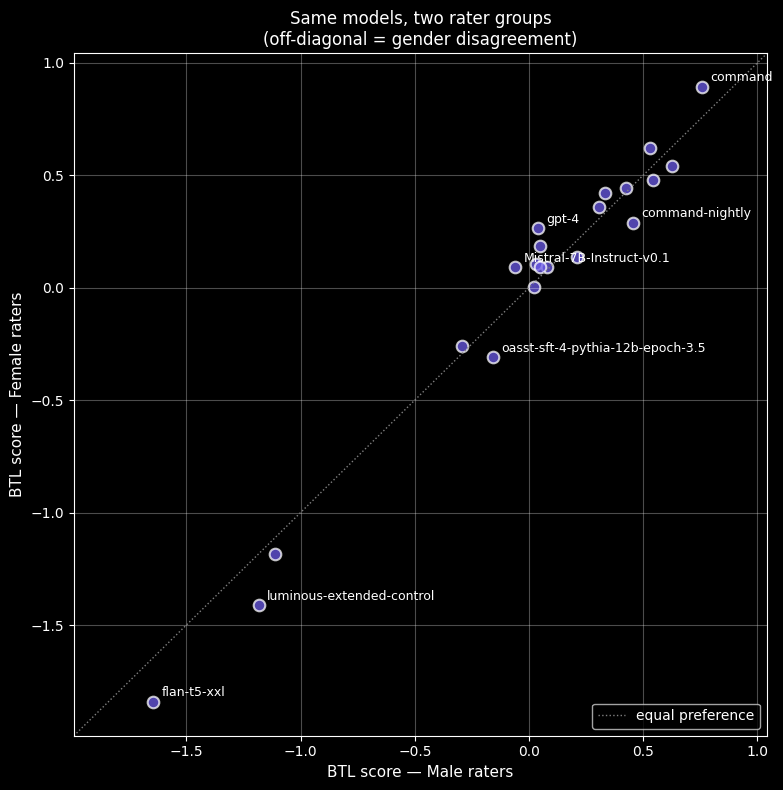

In [25]:
import matplotlib.pyplot as plt

# Display-friendly model names
short = [m.split("/")[-1] for m in models]

fig, ax = plt.subplots(figsize=(8, 8))

# Diagonal = "no gender difference"
lo = min(btl_male.min(), btl_female.min()) - 0.15
hi = max(btl_male.max(), btl_female.max()) + 0.15
ax.plot([lo, hi], [lo, hi], color="gray", linestyle=":", linewidth=1, label="equal preference")

ax.scatter(btl_male, btl_female, s=70, color="#6c5ce7", alpha=0.75, edgecolor="white", linewidth=1.5)

# Highlight the most off-diagonal models with labels
diff = btl_female - btl_male  # positive = women prefer relatively more
to_label = set(np.argsort(-np.abs(diff))[:6]) | {int(np.argmax(btl_male)), int(np.argmax(btl_female))}
for i in to_label:
    ax.annotate(short[i], (btl_male[i], btl_female[i]),
                fontsize=9, xytext=(6, 4), textcoords="offset points")

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("BTL score — Male raters", fontsize=11)
ax.set_ylabel("BTL score — Female raters", fontsize=11)
ax.set_title("Same models, two rater groups\n(off-diagonal = gender disagreement)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### What the plot shows

- **Strong overall agreement.** Spearman rank correlation between the two BTL rankings is ~0.95 — male and female raters mostly order the 21 LLMs the same way. Both pick `command` (Cohere) as #1.
- **The disagreements are systematic, not random.** A handful of models sit clearly above or below the diagonal:
  - Above the line (preferred more by women): **gpt-4** is the most striking — women rate it noticeably above its male average. `mistral-7B-instruct` and `zephyr-7b-beta` also tilt this way.
  - Below the line (preferred more by men): the worst-rated models (`luminous-extended-control`, `flan-t5-xxl`) sit further below — men dislike them somewhat less than women do.

### Why this matters

This is the empirical version of *"different people prefer different aligned models"* — Kirk et al.'s second case study, now directly visible in the data. Standard RLHF would average male and female preferences into a single reward model. The closer the two rankings, the less is lost in the average; the further apart, the more a single global reward suppresses one group's preferences in favour of the other.

In this PRISM slice the disagreement is moderate — but for any prompt subset where it is larger (say, values-guided or controversy-guided conversations), the same plot would show wider spread and the case for **per-subgroup reward models** (one of Conitzer et al.'s open agenda items) gets stronger.


### §7.2 Community Alignment (Zhang et al. 2026) — does response choice depend on country?

**The dataset.** 233,319 pairwise comparisons from 3,603 annotators across 5 countries (US, France, Italy, Brazil, India) and 5 languages. Each row is a full multi-turn conversation; the four candidate responses are anonymous (`response_a`, `response_b`, `response_c`, `response_d`). Uses **negatively-correlated (NC) sampling** — candidates are deliberately spread along value dimensions, so observed preferences carry information about value variation rather than stylistic differences.

🤗 [huggingface.co/datasets/facebook/community-alignment-dataset](https://huggingface.co/datasets/facebook/community-alignment-dataset) · 📄 [arXiv:2507.09650](https://arxiv.org/abs/2507.09650)

> ⚠ **Download size: ~1.8 GB.** The CSV holds 90k conversations × 16 long response texts each. First run takes a few minutes; cached after that. Skip the next two cells if you don't want the download right now.

Without model attribution we can't run model-level Bradley–Terry the way we did for PRISM. But we *can* look at *who chooses what* — annotator demographics × candidate-position preferences across the 5 countries.


In [26]:
# Download Community Alignment csv (~15 MB), cached locally to ./data/.
ca_path = hf_hub_download(
    repo_id="facebook/community-alignment-dataset",
    filename="community_alignment.csv",
    repo_type="dataset",
    cache_dir=str(DATA_DIR),
)
print(f"Community Alignment cached at:\n  {ca_path}")


Community Alignment cached at:
  /Users/carinah/projects/konstanz-fairness-collective-ai/notebooks/04_preference_aggregation/data/datasets--facebook--community-alignment-dataset/snapshots/97343c7f6399fcbea430ed0f37c1768281a78d56/community_alignment.csv


In [27]:
import csv
from collections import Counter

# Load only the relevant columns
relevant = [
    "annotator_country", "annotator_age", "assigned_lang",
    "first_turn_preferred_response",
]
rows = []
with open(ca_path) as f:
    reader = csv.DictReader(f)
    for r in reader:
        rows.append({k: r[k] for k in relevant})

print(f"{len(rows):,} conversations\n")

# Distribution of preferred response position (a/b/c/d)
print("First-turn preferred-response distribution (overall):")
for pos, n in sorted(Counter(r["first_turn_preferred_response"] for r in rows).items()):
    print(f"  {pos}: {n:>6,} ({100*n/len(rows):.1f}%)")

# By country: does response choice vary?
print("\nFirst-turn preferred-response distribution by country (top 5 countries):")
by_country = defaultdict(Counter)
for r in rows:
    by_country[r["annotator_country"]][r["first_turn_preferred_response"]] += 1
top5_countries = sorted(by_country.items(), key=lambda x: -sum(x[1].values()))[:5]
print(f"{'country':<15}{'a':>8}{'b':>8}{'c':>8}{'d':>8}")
print("-" * 47)
for country, counts in top5_countries:
    total = sum(counts.values())
    pcts = {pos: 100 * counts.get(f"response_{pos}", 0) / total for pos in "abcd"}
    print(f"{country:<15}{pcts['a']:>7.1f}%{pcts['b']:>7.1f}%{pcts['c']:>7.1f}%{pcts['d']:>7.1f}%")


90,256 conversations

First-turn preferred-response distribution (overall):
  :    627 (0.7%)
  response_a: 26,849 (29.7%)
  response_b: 16,047 (17.8%)
  response_c: 15,554 (17.2%)
  response_d: 31,179 (34.5%)

First-turn preferred-response distribution by country (top 5 countries):
country               a       b       c       d
-----------------------------------------------
india             33.1%   17.4%   17.1%   31.7%
brazil            26.0%   18.4%   17.7%   36.8%
italy             25.8%   18.8%   17.5%   37.2%
united states     32.6%   16.6%   16.5%   34.2%
france            28.1%   18.1%   17.5%   35.7%


**What the country breakdown shows.** If response position were chosen at random (no model effect, no annotator effect) every country's row would be near 25/25/25/25. Systematic deviation across countries means *the same four responses are received differently by raters from different cultural backgrounds* — the algorithmic-monoculture lesson from Zhang et al. 2026.

To do *model-level* aggregation on Community Alignment, you need the response-to-model mapping documented in the dataset's [README on HuggingFace](https://huggingface.co/datasets/facebook/community-alignment-dataset). Once mapped, the same four-rule machinery from §3.1–§3.4 applies directly.

---

## §8 — What to try next

- **Subgroup aggregation on PRISM.** Re-run the four rules on demographic subsets (gender × country, or by religion). Does the BTL ranking shift? By how much — Spearman correlation, or rank-of-#1 stability?
- **Cross-rule disagreement metric on PRISM.** For each prompt where two rules pick different winners, compute the "switch cost" — how often does the disagreement come down to the bottom two ranks vs. the top? The empirical version of [Conitzer et al. 2024](https://arxiv.org/abs/2404.10271).
- **Pluralism vs candidate diversity (Community Alignment).** Subset to NC-sampled vs ordinary pairs and compute the fraction of pairs where Borda and BTL would pick different winners. Does diverse candidate sampling make rule choice matter *more* (preferences become richer) or *less* (the "right" answer is clearer)?
- **Bridge to Donahue (Week 5).** Donahue's "weighted winrate" is one specific reweighting of Plurality. Implement it on PRISM and see whether it would flip the leaderboard.
